# Etapa 1 - Leitura e inspeção inicial da base

## Inicializacao do ambiente Spark

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("PySpark Transactions Classification")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .getOrCreate()
)

## Leitura da base de dados

In [58]:
# A leitura via CSV foi usada apenas na etapa inicial de conversao;
# depois disso, mantemos a leitura em Parquet por melhor performance no Spark.

# dataframe = (
#     spark.read
#     .csv("./synthetic_fraud_data.csv", header=True, inferSchema=True)
# )
#
# dataframe.write.parquet("synthetic_fraud_data.parquet")

dataframe = (
    spark.read
    .parquet("./synthetic_fraud_data.parquet")
)

dataframe.createOrReplaceTempView("transactions_raw")

rows_count = dataframe.count()
print(f"Número de linhas no DataFrame: {rows_count}")

Número de linhas no DataFrame: 7483766


## Estrutura e visualização inicial da base

In [3]:
dataframe.printSchema()
# inferSchema acertou todos os tipos

root
 |-- transaction_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- card_number: long (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- merchant_category: string (nullable = true)
 |-- merchant_type: string (nullable = true)
 |-- merchant: string (nullable = true)
 |-- amount: double (nullable = true)
 |-- currency: string (nullable = true)
 |-- country: string (nullable = true)
 |-- city: string (nullable = true)
 |-- city_size: string (nullable = true)
 |-- card_type: string (nullable = true)
 |-- card_present: boolean (nullable = true)
 |-- device: string (nullable = true)
 |-- channel: string (nullable = true)
 |-- device_fingerprint: string (nullable = true)
 |-- ip_address: string (nullable = true)
 |-- distance_from_home: integer (nullable = true)
 |-- high_risk_merchant: boolean (nullable = true)
 |-- transaction_hour: integer (nullable = true)
 |-- weekend_transaction: boolean (nullable = true)
 |-- velocity_last_hour: string (nu

In [4]:
dataframe.show()

+--------------+-----------+----------------+--------------------+-----------------+-------------+--------------------+---------+--------+---------+------------+---------+---------------+------------+-----------+-------+--------------------+---------------+------------------+------------------+----------------+-------------------+--------------------+--------+
|transaction_id|customer_id|     card_number|           timestamp|merchant_category|merchant_type|            merchant|   amount|currency|  country|        city|city_size|      card_type|card_present|     device|channel|  device_fingerprint|     ip_address|distance_from_home|high_risk_merchant|transaction_hour|weekend_transaction|  velocity_last_hour|is_fraud|
+--------------+-----------+----------------+--------------------+-----------------+-------------+--------------------+---------+--------+---------+------------+---------+---------------+------------+-----------+-------+--------------------+---------------+-----------------

## Analise inicial da coluna alvo, nulos e duplicatas

In [5]:
spark.sql("SELECT is_fraud ,COUNT(is_fraud) FROM transactions_raw GROUP BY is_fraud ORDER BY is_fraud").show()

+--------+---------------+
|is_fraud|count(is_fraud)|
+--------+---------------+
|   false|        5989047|
|    true|        1494719|
+--------+---------------+



In [6]:
spark.sql("""
    SELECT
        SUM(CASE WHEN transaction_id IS NULL THEN 1 ELSE 0 END) AS transaction_id_nulls,
        SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) AS customer_id_nulls,
        SUM(CASE WHEN card_number IS NULL THEN 1 ELSE 0 END) AS card_number_nulls,
        SUM(CASE WHEN timestamp IS NULL THEN 1 ELSE 0 END) AS timestamp_nulls,
        SUM(CASE WHEN merchant_category IS NULL THEN 1 ELSE 0 END) AS merchant_category_nulls,
        SUM(CASE WHEN merchant_type IS NULL THEN 1 ELSE 0 END) AS merchant_type_nulls,
        SUM(CASE WHEN merchant IS NULL THEN 1 ELSE 0 END) AS merchant_nulls,
        SUM(CASE WHEN amount IS NULL THEN 1 ELSE 0 END) AS amount_nulls,
        SUM(CASE WHEN currency IS NULL THEN 1 ELSE 0 END) AS currency_nulls,
        SUM(CASE WHEN country IS NULL THEN 1 ELSE 0 END) AS country_nulls,
        SUM(CASE WHEN city IS NULL THEN 1 ELSE 0 END) AS city_nulls,
        SUM(CASE WHEN city_size IS NULL THEN 1 ELSE 0 END) AS city_size_nulls,
        SUM(CASE WHEN card_type IS NULL THEN 1 ELSE 0 END) AS card_type_nulls,
        SUM(CASE WHEN card_present IS NULL THEN 1 ELSE 0 END) AS card_present_nulls,
        SUM(CASE WHEN device IS NULL THEN 1 ELSE 0 END) AS device_nulls,
        SUM(CASE WHEN channel IS NULL THEN 1 ELSE 0 END) AS channel_nulls,
        SUM(CASE WHEN device_fingerprint IS NULL THEN 1 ELSE 0 END) AS device_fingerprint_nulls,
        SUM(CASE WHEN ip_address IS NULL THEN 1 ELSE 0 END) AS ip_address_nulls,
        SUM(CASE WHEN distance_from_home IS NULL THEN 1 ELSE 0 END) AS distance_from_home_nulls,
        SUM(CASE WHEN high_risk_merchant IS NULL THEN 1 ELSE 0 END) AS high_risk_merchant_nulls,
        SUM(CASE WHEN transaction_hour IS NULL THEN 1 ELSE 0 END) AS transaction_hour_nulls,
        SUM(CASE WHEN weekend_transaction IS NULL THEN 1 ELSE 0 END) AS weekend_transaction_nulls,
        SUM(CASE WHEN velocity_last_hour IS NULL THEN 1 ELSE 0 END) AS velocity_last_hour_nulls,
        SUM(CASE WHEN is_fraud IS NULL THEN 1 ELSE 0 END) AS is_fraud_nulls
    FROM transactions_raw
""").show(truncate=False, vertical=True)

-RECORD 0------------------------
 transaction_id_nulls      | 0   
 customer_id_nulls         | 0   
 card_number_nulls         | 0   
 timestamp_nulls           | 0   
 merchant_category_nulls   | 0   
 merchant_type_nulls       | 0   
 merchant_nulls            | 0   
 amount_nulls              | 0   
 currency_nulls            | 0   
 country_nulls             | 0   
 city_nulls                | 0   
 city_size_nulls           | 0   
 card_type_nulls           | 0   
 card_present_nulls        | 0   
 device_nulls              | 0   
 channel_nulls             | 0   
 device_fingerprint_nulls  | 0   
 ip_address_nulls          | 0   
 distance_from_home_nulls  | 0   
 high_risk_merchant_nulls  | 0   
 transaction_hour_nulls    | 0   
 weekend_transaction_nulls | 0   
 velocity_last_hour_nulls  | 0   
 is_fraud_nulls            | 0   



In [7]:
spark.sql("""
    SELECT COUNT(*) AS duplicated_rows
    FROM (
        SELECT
            transaction_id, customer_id, card_number, timestamp, merchant_category,
            merchant_type, merchant, amount, currency, country, city, city_size,
            card_type, card_present, device, channel, device_fingerprint, ip_address,
            distance_from_home, high_risk_merchant, transaction_hour,
            weekend_transaction, velocity_last_hour, is_fraud,
            COUNT(*) AS qty
        FROM transactions_raw
        GROUP BY
            transaction_id, customer_id, card_number, timestamp, merchant_category,
            merchant_type, merchant, amount, currency, country, city, city_size,
            card_type, card_present, device, channel, device_fingerprint, ip_address,
            distance_from_home, high_risk_merchant, transaction_hour,
            weekend_transaction, velocity_last_hour, is_fraud
        HAVING COUNT(*) > 1
    ) t
""").show()

+---------------+
|duplicated_rows|
+---------------+
|              0|
+---------------+



## Limpeza inicial

In [8]:
spark.sql("""
    SELECT
        SUM(CASE WHEN TRIM(transaction_id) = '' THEN 1 ELSE 0 END) AS transaction_id_empty,
        SUM(CASE WHEN TRIM(customer_id) = '' THEN 1 ELSE 0 END) AS customer_id_empty,
        SUM(CASE WHEN TRIM(merchant_category) = '' THEN 1 ELSE 0 END) AS merchant_category_empty,
        SUM(CASE WHEN TRIM(merchant_type) = '' THEN 1 ELSE 0 END) AS merchant_type_empty,
        SUM(CASE WHEN TRIM(merchant) = '' THEN 1 ELSE 0 END) AS merchant_empty,
        SUM(CASE WHEN TRIM(currency) = '' THEN 1 ELSE 0 END) AS currency_empty,
        SUM(CASE WHEN TRIM(country) = '' THEN 1 ELSE 0 END) AS country_empty,
        SUM(CASE WHEN TRIM(city) = '' THEN 1 ELSE 0 END) AS city_empty,
        SUM(CASE WHEN TRIM(city_size) = '' THEN 1 ELSE 0 END) AS city_size_empty,
        SUM(CASE WHEN TRIM(card_type) = '' THEN 1 ELSE 0 END) AS card_type_empty,
        SUM(CASE WHEN TRIM(device) = '' THEN 1 ELSE 0 END) AS device_empty,
        SUM(CASE WHEN TRIM(channel) = '' THEN 1 ELSE 0 END) AS channel_empty,
        SUM(CASE WHEN TRIM(device_fingerprint) = '' THEN 1 ELSE 0 END) AS device_fingerprint_empty,
        SUM(CASE WHEN TRIM(ip_address) = '' THEN 1 ELSE 0 END) AS ip_address_empty,
        SUM(CASE WHEN TRIM(velocity_last_hour) = '' THEN 1 ELSE 0 END) AS velocity_last_hour_empty
    FROM transactions_raw
""").show(truncate=False, vertical=True)

-RECORD 0-----------------------
 transaction_id_empty     | 0   
 customer_id_empty        | 0   
 merchant_category_empty  | 0   
 merchant_type_empty      | 0   
 merchant_empty           | 0   
 currency_empty           | 0   
 country_empty            | 0   
 city_empty               | 0   
 city_size_empty          | 0   
 card_type_empty          | 0   
 device_empty             | 0   
 channel_empty            | 0   
 device_fingerprint_empty | 0   
 ip_address_empty         | 0   
 velocity_last_hour_empty | 0   



# Etapa 2 - Pre-processamento e selecao inicial de atributos

## Selecao inicial de features

In [9]:
selected_dataframe = spark.sql("""
    SELECT
        merchant_category,
        merchant_type,
        amount,
        currency,
        country,
        city,
        city_size,
        card_type,
        card_present,
        device,
        channel,
        distance_from_home,
        high_risk_merchant,
        transaction_hour,
        weekend_transaction,
        velocity_last_hour,
        is_fraud
    FROM transactions_raw
""")

selected_dataframe.createOrReplaceTempView("transactions_selected")

In [10]:
spark.sql("SELECT * FROM transactions_selected LIMIT 10").show(truncate=False)

+-----------------+-------------+---------+--------+---------+------------+---------+---------------+------------+-----------+-------+------------------+------------------+----------------+-------------------+------------------------------------------------------------------------------------------------------------------------------------------------------+--------+
|merchant_category|merchant_type|amount   |currency|country  |city        |city_size|card_type      |card_present|device     |channel|distance_from_home|high_risk_merchant|transaction_hour|weekend_transaction|velocity_last_hour                                                                                                                                    |is_fraud|
+-----------------+-------------+---------+--------+---------+------------+---------+---------------+------------+-----------+-------+------------------+------------------+----------------+-------------------+---------------------------------------------------

## Inspecao inicial de velocity_last_hour

In [11]:
spark.sql("SELECT velocity_last_hour FROM transactions_selected LIMIT 10").show(truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------+
|velocity_last_hour                                                                                                                                    |
+------------------------------------------------------------------------------------------------------------------------------------------------------+
|{'num_transactions': 222, 'total_amount': 6001328.808632168, 'unique_merchants': 87, 'unique_countries': 12, 'max_single_amount': 1108920.8766736432} |
|{'num_transactions': 110, 'total_amount': 6437171.840036886, 'unique_merchants': 70, 'unique_countries': 9, 'max_single_amount': 2574176.473608244}   |
|{'num_transactions': 268, 'total_amount': 12635383.309312332, 'unique_merchants': 94, 'unique_countries': 12, 'max_single_amount': 3419844.28627481}  |
|{'num_transactions': 21, 'total_amount': 223751.77196771436, 'unique_merchants': 

In [12]:
velocity_preview_dataframe = spark.sql("""
    SELECT
        velocity_last_hour,
        velocity_struct.num_transactions AS num_transactions_last_hour,
        velocity_struct.total_amount AS total_amount_last_hour,
        velocity_struct.unique_merchants AS unique_merchants_last_hour,
        velocity_struct.unique_countries AS unique_countries_last_hour,
        velocity_struct.max_single_amount AS max_single_amount_last_hour
    FROM (
        SELECT
            velocity_last_hour,
            from_json(
                replace(velocity_last_hour, '''', '"'),
                'num_transactions INT, total_amount DOUBLE, unique_merchants INT, unique_countries INT, max_single_amount DOUBLE'
            ) AS velocity_struct
        FROM transactions_selected
    ) t
    LIMIT 10
""")

velocity_preview_dataframe.show(truncate=False)

+------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------+----------------------+--------------------------+--------------------------+---------------------------+
|velocity_last_hour                                                                                                                                    |num_transactions_last_hour|total_amount_last_hour|unique_merchants_last_hour|unique_countries_last_hour|max_single_amount_last_hour|
+------------------------------------------------------------------------------------------------------------------------------------------------------+--------------------------+----------------------+--------------------------+--------------------------+---------------------------+
|{'num_transactions': 222, 'total_amount': 6001328.808632168, 'unique_merchants': 87, 'unique_countries': 12, 'max_single_amount': 1108920.876673

## Criacao da view tratada para a modelagem

In [13]:
treated_dataframe = spark.sql("""
    SELECT
        merchant_category,
        merchant_type,
        amount,
        currency,
        country,
        city,
        city_size,
        card_type,
        card_present,
        device,
        channel,
        distance_from_home,
        high_risk_merchant,
        transaction_hour,
        weekend_transaction,
        velocity_struct.num_transactions AS num_transactions_last_hour,
        velocity_struct.total_amount AS total_amount_last_hour,
        velocity_struct.unique_merchants AS unique_merchants_last_hour,
        velocity_struct.unique_countries AS unique_countries_last_hour,
        velocity_struct.max_single_amount AS max_single_amount_last_hour,
        is_fraud
    FROM (
        SELECT
            merchant_category,
            merchant_type,
            amount,
            currency,
            country,
            city,
            city_size,
            card_type,
            card_present,
            device,
            channel,
            distance_from_home,
            high_risk_merchant,
            transaction_hour,
            weekend_transaction,
            from_json(
                replace(velocity_last_hour, '''', '"'),
                'num_transactions INT, total_amount DOUBLE, unique_merchants INT, unique_countries INT, max_single_amount DOUBLE'
            ) AS velocity_struct,
            is_fraud
        FROM transactions_selected
    ) t
""")

treated_dataframe.createOrReplaceTempView("transactions_treated")

In [14]:
spark.sql("DESCRIBE transactions_treated").show(truncate=False)
spark.sql("SELECT * FROM transactions_treated LIMIT 10").show(truncate=False)

+---------------------------+---------+-------+
|col_name                   |data_type|comment|
+---------------------------+---------+-------+
|merchant_category          |string   |NULL   |
|merchant_type              |string   |NULL   |
|amount                     |double   |NULL   |
|currency                   |string   |NULL   |
|country                    |string   |NULL   |
|city                       |string   |NULL   |
|city_size                  |string   |NULL   |
|card_type                  |string   |NULL   |
|card_present               |boolean  |NULL   |
|device                     |string   |NULL   |
|channel                    |string   |NULL   |
|distance_from_home         |int      |NULL   |
|high_risk_merchant         |boolean  |NULL   |
|transaction_hour           |int      |NULL   |
|weekend_transaction        |boolean  |NULL   |
|num_transactions_last_hour |int      |NULL   |
|total_amount_last_hour     |double   |NULL   |
|unique_merchants_last_hour |int      |N

## Validacao do tratamento de velocity_last_hour

In [15]:
spark.sql("""
    SELECT
        SUM(CASE WHEN num_transactions_last_hour IS NULL THEN 1 ELSE 0 END) AS num_transactions_last_hour_nulls,
        SUM(CASE WHEN total_amount_last_hour IS NULL THEN 1 ELSE 0 END) AS total_amount_last_hour_nulls,
        SUM(CASE WHEN unique_merchants_last_hour IS NULL THEN 1 ELSE 0 END) AS unique_merchants_last_hour_nulls,
        SUM(CASE WHEN unique_countries_last_hour IS NULL THEN 1 ELSE 0 END) AS unique_countries_last_hour_nulls,
        SUM(CASE WHEN max_single_amount_last_hour IS NULL THEN 1 ELSE 0 END) AS max_single_amount_last_hour_nulls
    FROM transactions_treated
""").show(truncate=False, vertical=True)

-RECORD 0--------------------------------
 num_transactions_last_hour_nulls  | 0   
 total_amount_last_hour_nulls      | 0   
 unique_merchants_last_hour_nulls  | 0   
 unique_countries_last_hour_nulls  | 0   
 max_single_amount_last_hour_nulls | 0   



# Etapa 3 - Analise exploratoria de dados

## Configuracao dos graficos com Matplotlib

In [16]:
import matplotlib.pyplot as plt

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

PLOT_COLORS = {
    "primary": "#2563eb",
    "risk": "#dc2626",
    "success": "#16a34a",
    "warning": "#f59e0b",
    "muted": "#64748b",
}

def format_integer(value):
    return f"{int(value):,}".replace(",", ".")

def fraud_class_label(value):
    return "Fraude" if value else "Nao fraude"

def bool_label(value):
    if value is True:
        return "True"
    if value is False:
        return "False"
    return str(value)

def label_vertical_bars(ax, bars, labels=None, decimals=2):
    for index, bar in enumerate(bars):
        height = bar.get_height()
        label = labels[index] if labels is not None else f"{height:.{decimals}f}"
        ax.annotate(
            label,
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
        )

def label_horizontal_bars(ax, bars, values, suffix="%"):
    for bar, value in zip(bars, values):
        ax.annotate(
            f"{value:.2f}{suffix}",
            xy=(bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=9,
        )

## Distribuicao da classe alvo

In [17]:
spark.sql("""
    SELECT
        is_fraud,
        total_transactions,
        ROUND(100.0 * total_transactions / SUM(total_transactions) OVER (), 2) AS percentage
    FROM (
        SELECT
            is_fraud,
            COUNT(*) AS total_transactions
        FROM transactions_treated
        GROUP BY is_fraud
    ) t
    ORDER BY is_fraud
""").show(truncate=False)

+--------+------------------+----------+
|is_fraud|total_transactions|percentage|
+--------+------------------+----------+
|false   |5989047           |80.03     |
|true    |1494719           |19.97     |
+--------+------------------+----------+



### Grafico da distribuicao da classe alvo

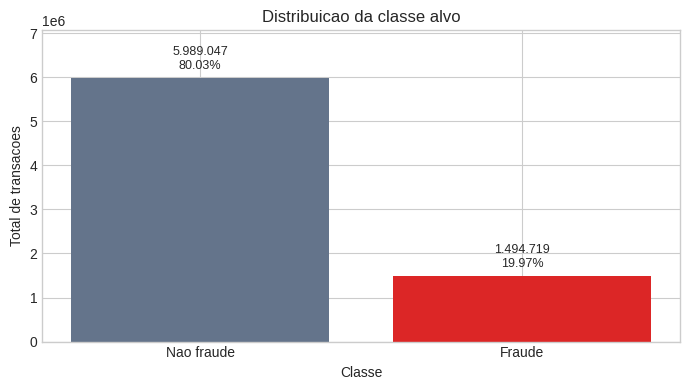

In [18]:
class_distribution_rows = spark.sql("""
    SELECT
        is_fraud,
        total_transactions,
        ROUND(100.0 * total_transactions / SUM(total_transactions) OVER (), 2) AS percentage
    FROM (
        SELECT
            is_fraud,
            COUNT(*) AS total_transactions
        FROM transactions_treated
        GROUP BY is_fraud
    ) t
    ORDER BY is_fraud
""").collect()

class_labels = [fraud_class_label(row["is_fraud"]) for row in class_distribution_rows]
class_counts = [row["total_transactions"] for row in class_distribution_rows]
class_percentages = [float(row["percentage"]) for row in class_distribution_rows]
class_colors = [PLOT_COLORS["risk"] if label == "Fraude" else PLOT_COLORS["muted"] for label in class_labels]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(class_labels, class_counts, color=class_colors)
labels = [
    f"{format_integer(count)}" + chr(10) + f"{percentage:.2f}%"
    for count, percentage in zip(class_counts, class_percentages)
]
label_vertical_bars(ax, bars, labels=labels)

ax.set_title("Distribuicao da classe alvo")
ax.set_xlabel("Classe")
ax.set_ylabel("Total de transacoes")
ax.set_ylim(0, max(class_counts) * 1.18)
plt.tight_layout()
plt.show()

## Estatisticas das variaveis numericas por classe

In [19]:
spark.sql("""
    SELECT
        is_fraud,
        ROUND(AVG(amount), 2) AS avg_amount,
        ROUND(MIN(amount), 2) AS min_amount,
        ROUND(MAX(amount), 2) AS max_amount,
        ROUND(AVG(distance_from_home), 2) AS avg_distance_from_home,
        ROUND(AVG(num_transactions_last_hour), 2) AS avg_num_transactions_last_hour,
        ROUND(AVG(total_amount_last_hour), 2) AS avg_total_amount_last_hour,
        ROUND(AVG(max_single_amount_last_hour), 2) AS avg_max_single_amount_last_hour
    FROM transactions_treated
    GROUP BY is_fraud
    ORDER BY is_fraud
""").show(truncate=False)

+--------+----------+----------+----------+----------------------+------------------------------+--------------------------+-------------------------------+
|is_fraud|avg_amount|min_amount|max_amount|avg_distance_from_home|avg_num_transactions_last_hour|avg_total_amount_last_hour|avg_max_single_amount_last_hour|
+--------+----------+----------+----------+----------------------+------------------------------+--------------------------+-------------------------------+
|false   |30242.54  |17.95     |1240629.47|0.17                  |408.26                        |1.985783734E7             |1719986.75                     |
|true    |118773.59 |0.01      |6253152.62|0.92                  |412.67                        |2.015499552E7             |1752255.49                     |
+--------+----------+----------+----------+----------------------+------------------------------+--------------------------+-------------------------------+



### Grafico de valores numericos por classe

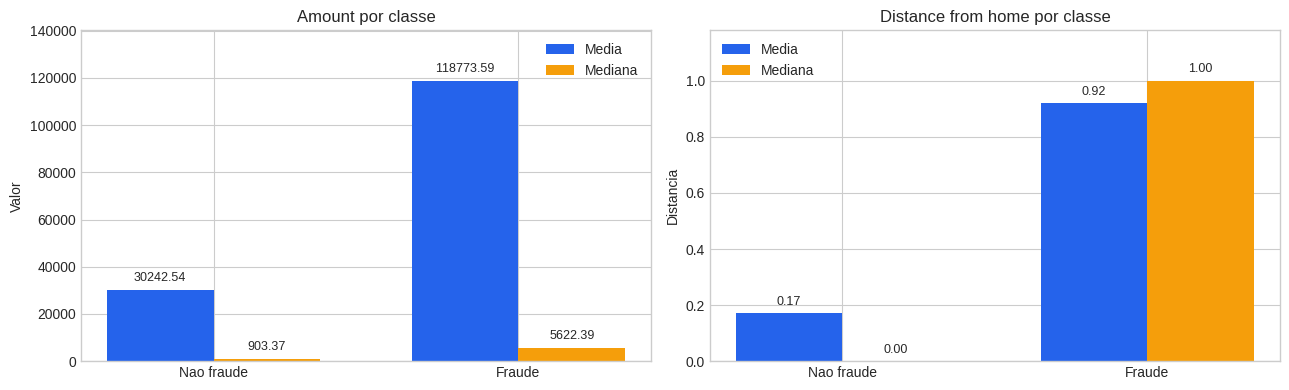

In [20]:
numeric_profile_rows = spark.sql("""
    SELECT
        is_fraud,
        ROUND(AVG(amount), 2) AS avg_amount,
        ROUND(percentile_approx(amount, 0.5), 2) AS median_amount,
        ROUND(AVG(distance_from_home), 2) AS avg_distance_from_home,
        ROUND(percentile_approx(distance_from_home, 0.5), 2) AS median_distance_from_home
    FROM transactions_treated
    GROUP BY is_fraud
    ORDER BY is_fraud
""").collect()

numeric_labels = [fraud_class_label(row["is_fraud"]) for row in numeric_profile_rows]
x_positions = list(range(len(numeric_labels)))
bar_width = 0.35

amount_average = [float(row["avg_amount"]) for row in numeric_profile_rows]
amount_median = [float(row["median_amount"]) for row in numeric_profile_rows]
distance_average = [float(row["avg_distance_from_home"]) for row in numeric_profile_rows]
distance_median = [float(row["median_distance_from_home"]) for row in numeric_profile_rows]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

amount_avg_bars = axes[0].bar(
    [position - bar_width / 2 for position in x_positions],
    amount_average,
    width=bar_width,
    label="Media",
    color=PLOT_COLORS["primary"],
)
amount_median_bars = axes[0].bar(
    [position + bar_width / 2 for position in x_positions],
    amount_median,
    width=bar_width,
    label="Mediana",
    color=PLOT_COLORS["warning"],
)
axes[0].set_title("Amount por classe")
axes[0].set_ylabel("Valor")
axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(numeric_labels)
axes[0].legend()
axes[0].set_ylim(0, max(amount_average + amount_median) * 1.18)
label_vertical_bars(axes[0], amount_avg_bars)
label_vertical_bars(axes[0], amount_median_bars)

distance_avg_bars = axes[1].bar(
    [position - bar_width / 2 for position in x_positions],
    distance_average,
    width=bar_width,
    label="Media",
    color=PLOT_COLORS["primary"],
)
distance_median_bars = axes[1].bar(
    [position + bar_width / 2 for position in x_positions],
    distance_median,
    width=bar_width,
    label="Mediana",
    color=PLOT_COLORS["warning"],
)
axes[1].set_title("Distance from home por classe")
axes[1].set_ylabel("Distancia")
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(numeric_labels)
axes[1].legend()
axes[1].set_ylim(0, max(distance_average + distance_median) * 1.18)
label_vertical_bars(axes[1], distance_avg_bars)
label_vertical_bars(axes[1], distance_median_bars)

plt.tight_layout()
plt.show()

## Taxa de fraude por merchant_category

In [21]:
spark.sql("""
    SELECT
        merchant_category,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage
    FROM transactions_treated
    GROUP BY merchant_category
    ORDER BY fraud_rate_percentage DESC, total_transactions DESC
    LIMIT 15
""").show(truncate=False)

+-----------------+------------------+------------------+---------------------+
|merchant_category|total_transactions|fraud_transactions|fraud_rate_percentage|
+-----------------+------------------+------------------+---------------------+
|Travel           |935790            |187477            |20.03                |
|Grocery          |934029            |186987            |20.02                |
|Restaurant       |936178            |186951            |19.97                |
|Gas              |935401            |186829            |19.97                |
|Entertainment    |936173            |186890            |19.96                |
|Education        |933542            |186203            |19.95                |
|Healthcare       |936770            |186769            |19.94                |
|Retail           |935883            |186613            |19.94                |
+-----------------+------------------+------------------+---------------------+



### Grafico da taxa de fraude por merchant_category

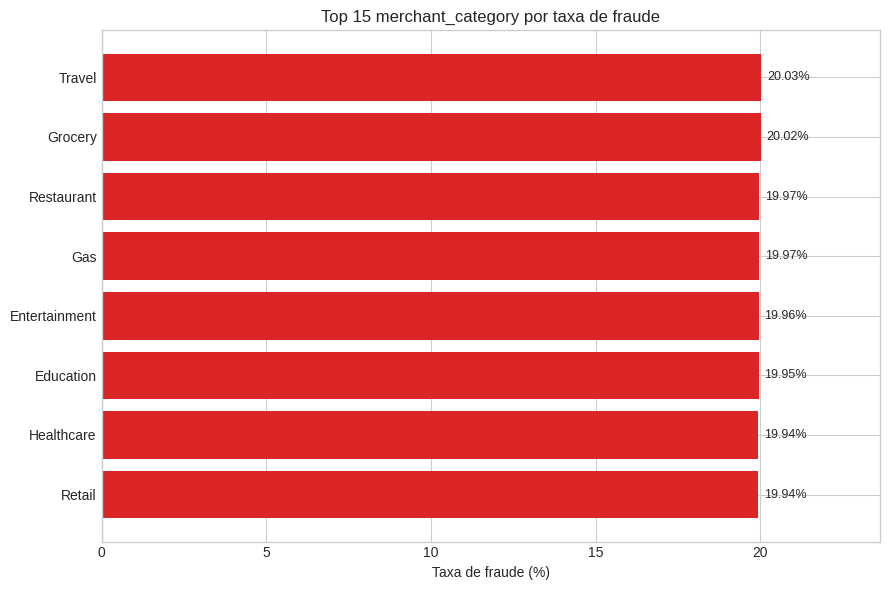

In [22]:
merchant_category_rows = spark.sql("""
    SELECT
        merchant_category,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage
    FROM transactions_treated
    GROUP BY merchant_category
    ORDER BY fraud_rate_percentage DESC, total_transactions DESC
    LIMIT 15
""").collect()[::-1]

merchant_categories = [row["merchant_category"] for row in merchant_category_rows]
merchant_fraud_rates = [float(row["fraud_rate_percentage"]) for row in merchant_category_rows]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(merchant_categories, merchant_fraud_rates, color=PLOT_COLORS["risk"])
label_horizontal_bars(ax, bars, merchant_fraud_rates)
ax.set_title("Top 15 merchant_category por taxa de fraude")
ax.set_xlabel("Taxa de fraude (%)")
ax.set_xlim(0, max(merchant_fraud_rates) * 1.18)
plt.tight_layout()
plt.show()

## Taxa de fraude por channel

In [23]:
spark.sql("""
    SELECT
        channel,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage,
        ROUND(AVG(amount), 2) AS avg_amount
    FROM transactions_treated
    GROUP BY channel
    ORDER BY fraud_rate_percentage DESC, total_transactions DESC
""").show(truncate=False)

+-------+------------------+------------------+---------------------+----------+
|channel|total_transactions|fraud_transactions|fraud_rate_percentage|avg_amount|
+-------+------------------+------------------+---------------------+----------+
|pos    |651047            |651047            |100.00               |118930.25 |
|mobile |2269578           |281150            |12.39                |41842.23  |
|web    |4563141           |562522            |12.33                |40819.2   |
+-------+------------------+------------------+---------------------+----------+



### Taxa de fraude por device

In [24]:
spark.sql("""
    SELECT
        device,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage,
        ROUND(AVG(amount), 2) AS avg_amount
    FROM transactions_treated
    GROUP BY device
    ORDER BY fraud_rate_percentage DESC, total_transactions DESC
""").show(truncate=False)

+---------------+------------------+------------------+---------------------+----------+
|device         |total_transactions|fraud_transactions|fraud_rate_percentage|avg_amount|
+---------------+------------------+------------------+---------------------+----------+
|Chip Reader    |217324            |217324            |100.00               |119000.35 |
|Magnetic Stripe|217204            |217204            |100.00               |119552.15 |
|NFC Payment    |216519            |216519            |100.00               |118236.02 |
|Firefox        |1120952           |142171            |12.68                |40511.03  |
|Safari         |1120245           |141379            |12.62                |43041.82  |
|Android App    |1126117           |140844            |12.51                |42223.05  |
|Chrome         |1132384           |140087            |12.37                |39888.21  |
|iOS App        |1143461           |140306            |12.27                |41467.18  |
|Edge           |1189

### Grafico da taxa de fraude por channel e device

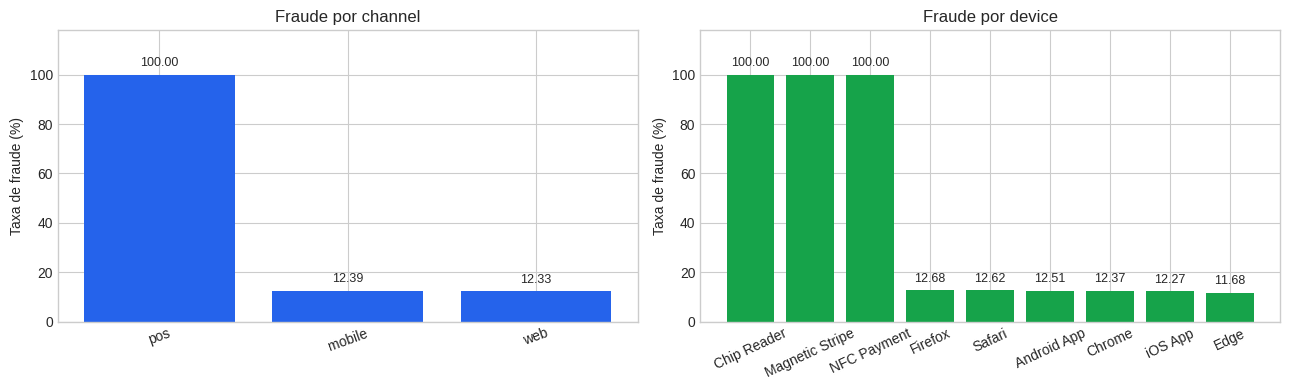

In [25]:
channel_rows = spark.sql("""
    SELECT
        channel,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage
    FROM transactions_treated
    GROUP BY channel
    ORDER BY fraud_rate_percentage DESC, total_transactions DESC
""").collect()

device_rows = spark.sql("""
    SELECT
        device,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage
    FROM transactions_treated
    GROUP BY device
    ORDER BY fraud_rate_percentage DESC, total_transactions DESC
""").collect()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

channel_labels = [row["channel"] for row in channel_rows]
channel_rates = [float(row["fraud_rate_percentage"]) for row in channel_rows]
channel_bars = axes[0].bar(channel_labels, channel_rates, color=PLOT_COLORS["primary"])
label_vertical_bars(axes[0], channel_bars)
axes[0].set_title("Fraude por channel")
axes[0].set_ylabel("Taxa de fraude (%)")
axes[0].set_ylim(0, max(channel_rates) * 1.18)
axes[0].tick_params(axis="x", rotation=20)

device_labels = [row["device"] for row in device_rows]
device_rates = [float(row["fraud_rate_percentage"]) for row in device_rows]
device_bars = axes[1].bar(device_labels, device_rates, color=PLOT_COLORS["success"])
label_vertical_bars(axes[1], device_bars)
axes[1].set_title("Fraude por device")
axes[1].set_ylabel("Taxa de fraude (%)")
axes[1].set_ylim(0, max(device_rates) * 1.18)
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

## Taxa de fraude por pais

In [26]:
spark.sql("""
    SELECT
        country,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage,
        ROUND(AVG(amount), 2) AS avg_amount
    FROM transactions_treated
    GROUP BY country
    ORDER BY fraud_rate_percentage DESC, total_transactions DESC
    LIMIT 15
""").show(truncate=False)

+---------+------------------+------------------+---------------------+----------+
|country  |total_transactions|fraud_transactions|fraud_rate_percentage|avg_amount|
+---------+------------------+------------------+---------------------+----------+
|Mexico   |785704            |298841            |38.03                |15179.9   |
|Russia   |793730            |299425            |37.72                |56661.24  |
|Brazil   |804800            |298629            |37.11                |3784.36   |
|Nigeria  |849840            |298600            |35.14                |308284.4  |
|Australia|496695            |37652             |7.58                 |791.69    |
|USA      |500060            |37312             |7.46                 |565.54    |
|Japan    |527393            |37592             |7.13                 |65310.79  |
|Germany  |524464            |37205             |7.09                 |502.4     |
|Canada   |532632            |37278             |7.00                 |696.53    |
|UK 

### Grafico da taxa de fraude por pais

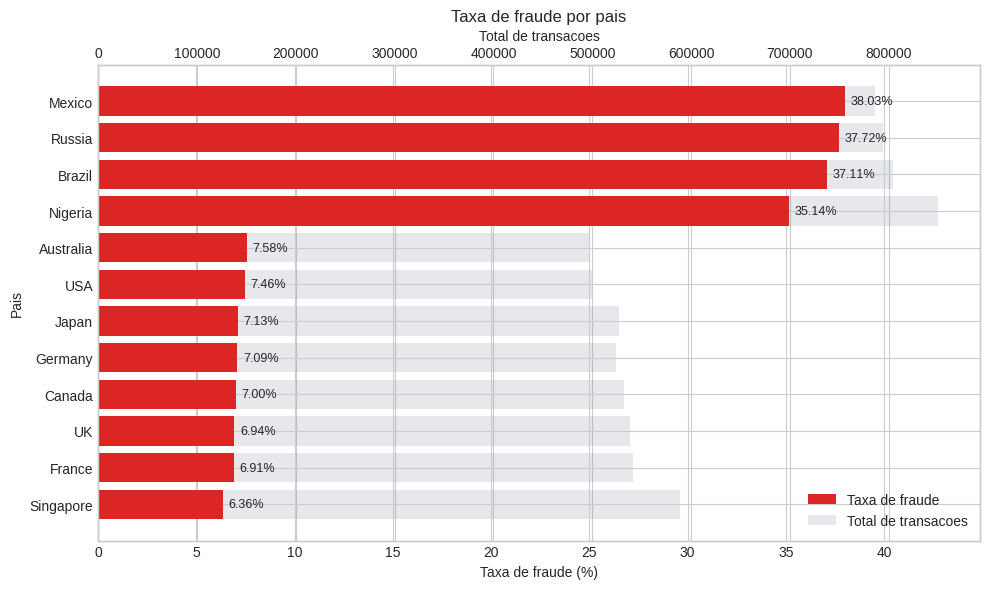

In [27]:
country_rows = spark.sql("""
    SELECT
        country,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage,
        ROUND(AVG(amount), 2) AS avg_amount
    FROM transactions_treated
    GROUP BY country
    ORDER BY fraud_rate_percentage ASC, total_transactions ASC
""").collect()

country_labels = [row["country"] for row in country_rows]
country_rates = [float(row["fraud_rate_percentage"]) for row in country_rows]
country_volumes = [row["total_transactions"] for row in country_rows]

fig, ax_rate = plt.subplots(figsize=(10, 6))
ax_volume = ax_rate.twiny()

volume_bars = ax_volume.barh(
    country_labels,
    country_volumes,
    color=PLOT_COLORS["muted"],
    alpha=0.16,
    label="Total de transacoes",
)
rate_bars = ax_rate.barh(
    country_labels,
    country_rates,
    color=PLOT_COLORS["risk"],
    label="Taxa de fraude",
)

label_horizontal_bars(ax_rate, rate_bars, country_rates)

ax_rate.set_title("Taxa de fraude por pais")
ax_rate.set_xlabel("Taxa de fraude (%)")
ax_rate.set_ylabel("Pais")
ax_volume.set_xlabel("Total de transacoes")
ax_rate.set_xlim(0, max(country_rates) * 1.18)
ax_rate.set_zorder(ax_volume.get_zorder() + 1)
ax_rate.patch.set_visible(False)

rate_handles, rate_labels = ax_rate.get_legend_handles_labels()
volume_handles, volume_labels = ax_volume.get_legend_handles_labels()
ax_rate.legend(rate_handles + volume_handles, rate_labels + volume_labels, loc="lower right")

plt.tight_layout()
plt.show()

## Comportamento por horario da transacao

In [28]:
spark.sql("""
    SELECT
        transaction_hour,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage,
        ROUND(AVG(amount), 2) AS avg_amount
    FROM transactions_treated
    GROUP BY transaction_hour
    ORDER BY transaction_hour
""").show(24, truncate=False)

+----------------+------------------+------------------+---------------------+----------+
|transaction_hour|total_transactions|fraud_transactions|fraud_rate_percentage|avg_amount|
+----------------+------------------+------------------+---------------------+----------+
|0               |155759            |41519             |26.66                |54766.09  |
|1               |280136            |165999            |59.26                |82479.77  |
|2               |280472            |166025            |59.19                |82206.57  |
|3               |280031            |165621            |59.14                |82835.45  |
|4               |281466            |166418            |59.13                |82583.89  |
|5               |208529            |41829             |20.06                |47522.96  |
|6               |196875            |41622             |21.14                |48576.98  |
|7               |301176            |41318             |13.72                |42111.48  |
|8        

### Grafico da taxa de fraude por horario

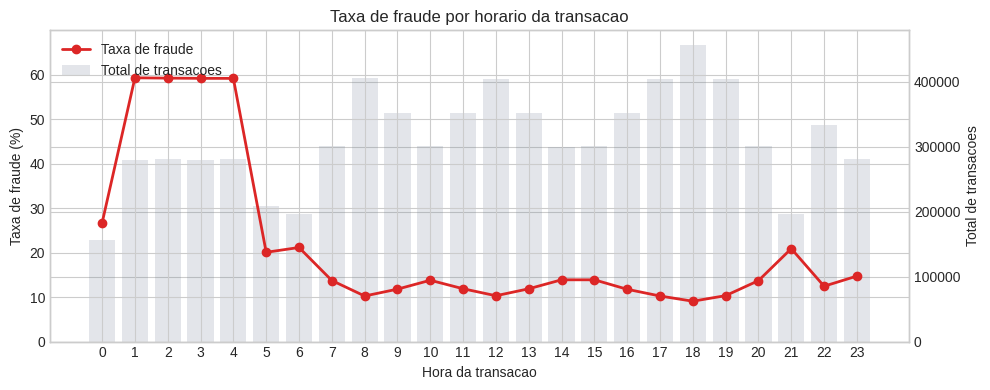

In [29]:
transaction_hour_rows = spark.sql("""
    SELECT
        transaction_hour,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage
    FROM transactions_treated
    GROUP BY transaction_hour
    ORDER BY transaction_hour
""").collect()

hours = [int(row["transaction_hour"]) for row in transaction_hour_rows]
fraud_rates = [float(row["fraud_rate_percentage"]) for row in transaction_hour_rows]
total_transactions = [row["total_transactions"] for row in transaction_hour_rows]

fig, ax_rate = plt.subplots(figsize=(10, 4))
ax_volume = ax_rate.twinx()

ax_volume.bar(hours, total_transactions, color=PLOT_COLORS["muted"], alpha=0.18, label="Total de transacoes")
ax_rate.plot(hours, fraud_rates, color=PLOT_COLORS["risk"], marker="o", linewidth=2, label="Taxa de fraude")
ax_rate.set_zorder(ax_volume.get_zorder() + 1)
ax_rate.patch.set_visible(False)

ax_rate.set_title("Taxa de fraude por horario da transacao")
ax_rate.set_xlabel("Hora da transacao")
ax_rate.set_ylabel("Taxa de fraude (%)")
ax_volume.set_ylabel("Total de transacoes")
ax_rate.set_xticks(hours)
ax_rate.set_ylim(0, max(fraud_rates) * 1.18)

rate_lines, rate_labels = ax_rate.get_legend_handles_labels()
volume_lines, volume_labels = ax_volume.get_legend_handles_labels()
ax_rate.legend(rate_lines + volume_lines, rate_labels + volume_labels, loc="upper left")

plt.tight_layout()
plt.show()

## Impacto das variaveis binarias

In [30]:
spark.sql("""
    SELECT
        high_risk_merchant,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage
    FROM transactions_treated
    GROUP BY high_risk_merchant
    ORDER BY high_risk_merchant
""").show(truncate=False)

spark.sql("""
    SELECT
        weekend_transaction,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage
    FROM transactions_treated
    GROUP BY weekend_transaction
    ORDER BY weekend_transaction
""").show(truncate=False)

spark.sql("""
    SELECT
        card_present,
        COUNT(*) AS total_transactions,
        SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
        ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage
    FROM transactions_treated
    GROUP BY card_present
    ORDER BY card_present
""").show(truncate=False)

+------------------+------------------+------------------+---------------------+
|high_risk_merchant|total_transactions|fraud_transactions|fraud_rate_percentage|
+------------------+------------------+------------------+---------------------+
|false             |5611803           |1120352           |19.96                |
|true              |1871963           |374367            |20.00                |
+------------------+------------------+------------------+---------------------+

+-------------------+------------------+------------------+---------------------+
|weekend_transaction|total_transactions|fraud_transactions|fraud_rate_percentage|
+-------------------+------------------+------------------+---------------------+
|false              |5554103           |1109277           |19.97                |
|true               |1929663           |385442            |19.97                |
+-------------------+------------------+------------------+---------------------+

+------------+------

### Grafico da taxa de fraude por variaveis binarias

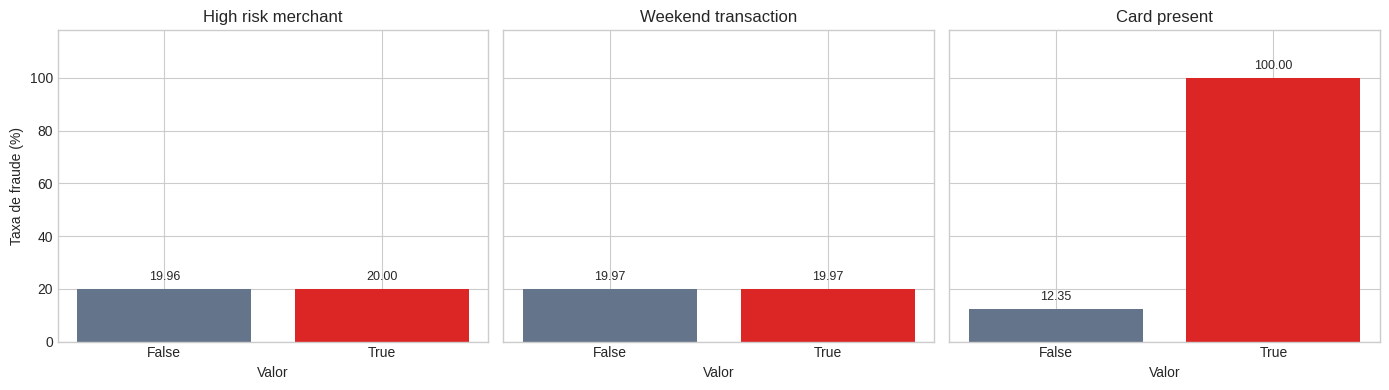

In [31]:
binary_columns = [
    ("high_risk_merchant", "High risk merchant"),
    ("weekend_transaction", "Weekend transaction"),
    ("card_present", "Card present"),
]

fig, axes = plt.subplots(1, len(binary_columns), figsize=(14, 4), sharey=True)

for ax, (column_name, column_title) in zip(axes, binary_columns):
    rows = spark.sql(f"""
        SELECT
            {column_name} AS variable_value,
            COUNT(*) AS total_transactions,
            SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) AS fraud_transactions,
            ROUND(100.0 * SUM(CASE WHEN is_fraud = true THEN 1 ELSE 0 END) / COUNT(*), 2) AS fraud_rate_percentage
        FROM transactions_treated
        GROUP BY {column_name}
        ORDER BY {column_name}
    """).collect()

    labels = [bool_label(row["variable_value"]) for row in rows]
    rates = [float(row["fraud_rate_percentage"]) for row in rows]
    bars = ax.bar(labels, rates, color=[PLOT_COLORS["muted"], PLOT_COLORS["risk"]][:len(labels)])
    label_vertical_bars(ax, bars)
    ax.set_title(column_title)
    ax.set_xlabel("Valor")
    ax.set_ylim(0, max(rates) * 1.18)

axes[0].set_ylabel("Taxa de fraude (%)")
plt.tight_layout()
plt.show()

## Heatmap de correlacao das variaveis numericas

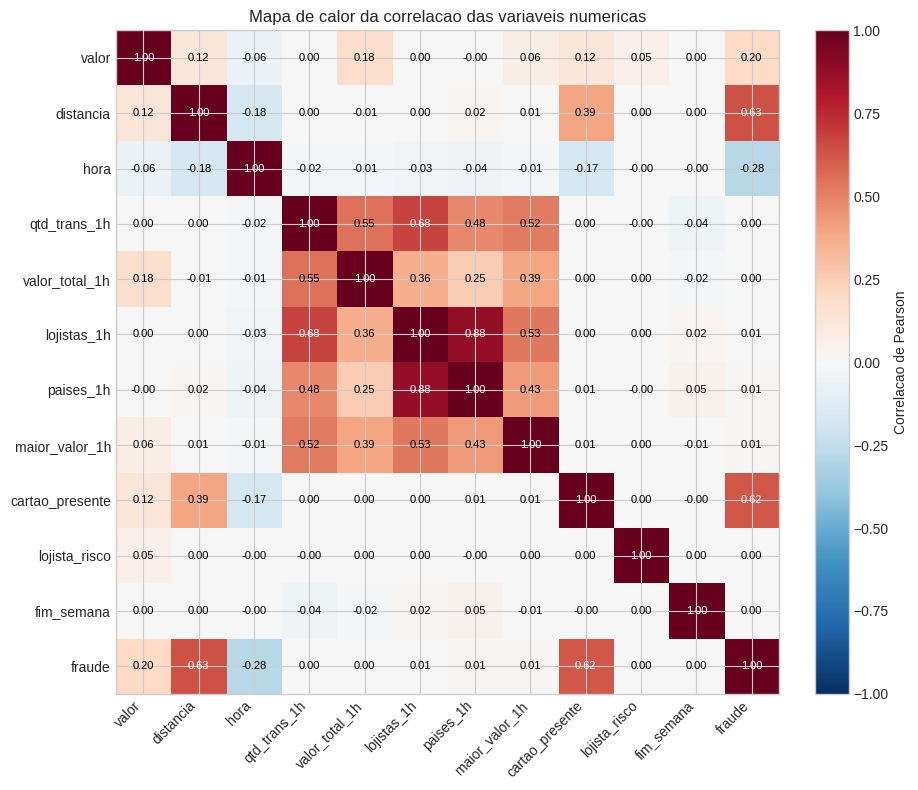

In [32]:
import numpy as np
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

numeric_corr_dataframe = spark.sql("""
    SELECT
        amount,
        distance_from_home,
        transaction_hour,
        num_transactions_last_hour,
        total_amount_last_hour,
        unique_merchants_last_hour,
        unique_countries_last_hour,
        max_single_amount_last_hour,
        CASE WHEN card_present = true THEN 1.0 ELSE 0.0 END AS card_present_num,
        CASE WHEN high_risk_merchant = true THEN 1.0 ELSE 0.0 END AS high_risk_merchant_num,
        CASE WHEN weekend_transaction = true THEN 1.0 ELSE 0.0 END AS weekend_transaction_num,
        CASE WHEN is_fraud = true THEN 1.0 ELSE 0.0 END AS label
    FROM transactions_treated
""")

numeric_corr_columns = [
    "amount",
    "distance_from_home",
    "transaction_hour",
    "num_transactions_last_hour",
    "total_amount_last_hour",
    "unique_merchants_last_hour",
    "unique_countries_last_hour",
    "max_single_amount_last_hour",
    "card_present_num",
    "high_risk_merchant_num",
    "weekend_transaction_num",
    "label"
]

corr_labels = [
    "valor",
    "distancia",
    "hora",
    "qtd_trans_1h",
    "valor_total_1h",
    "lojistas_1h",
    "paises_1h",
    "maior_valor_1h",
    "cartao_presente",
    "lojista_risco",
    "fim_semana",
    "fraude"
]

corr_assembler = VectorAssembler(
    inputCols=numeric_corr_columns,
    outputCol="corr_features"
)

corr_vector_dataframe = corr_assembler.transform(numeric_corr_dataframe).select("corr_features")
corr_matrix = Correlation.corr(corr_vector_dataframe, "corr_features", "pearson").head()[0].toArray()
corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)

fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colorbar.set_label("Correlacao de Pearson")

ax.set_title("Mapa de calor da correlacao das variaveis numericas")
ax.set_xticks(range(len(corr_labels)))
ax.set_yticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, rotation=45, ha="right")
ax.set_yticklabels(corr_labels)

for row_index in range(len(corr_labels)):
    for column_index in range(len(corr_labels)):
        value = corr_matrix[row_index, column_index]
        text_color = "white" if abs(value) >= 0.55 else "black"
        ax.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=8,
        )

plt.tight_layout()
plt.show()

# Etapa 4 - Divisao da base e balanceamento do treino

## Criacao da chave aleatoria para o split

In [33]:
split_dataframe = spark.sql("""
    SELECT
        *,
        rand(42) AS split_key
    FROM transactions_treated
""")

split_dataframe.createOrReplaceTempView("transactions_with_split")

## Separacao em treino e teste

In [34]:
train_dataframe = spark.sql("""
    SELECT
        merchant_category,
        merchant_type,
        amount,
        currency,
        country,
        city,
        city_size,
        card_type,
        card_present,
        device,
        channel,
        distance_from_home,
        high_risk_merchant,
        transaction_hour,
        weekend_transaction,
        num_transactions_last_hour,
        total_amount_last_hour,
        unique_merchants_last_hour,
        unique_countries_last_hour,
        max_single_amount_last_hour,
        is_fraud
    FROM transactions_with_split
    WHERE split_key < 0.80
""")

test_dataframe = spark.sql("""
    SELECT
        merchant_category,
        merchant_type,
        amount,
        currency,
        country,
        city,
        city_size,
        card_type,
        card_present,
        device,
        channel,
        distance_from_home,
        high_risk_merchant,
        transaction_hour,
        weekend_transaction,
        num_transactions_last_hour,
        total_amount_last_hour,
        unique_merchants_last_hour,
        unique_countries_last_hour,
        max_single_amount_last_hour,
        is_fraud
    FROM transactions_with_split
    WHERE split_key >= 0.80
""")

train_dataframe.createOrReplaceTempView("transactions_train")
test_dataframe.createOrReplaceTempView("transactions_test")

## Tamanho dos conjuntos

In [35]:
spark.sql("""
    SELECT
        dataset,
        total_transactions,
        ROUND(100.0 * total_transactions / SUM(total_transactions) OVER (), 2) AS percentage
    FROM (
        SELECT 'train' AS dataset, COUNT(*) AS total_transactions FROM transactions_train
        UNION ALL
        SELECT 'test' AS dataset, COUNT(*) AS total_transactions FROM transactions_test
    ) t
    ORDER BY dataset
""").show(truncate=False)

+-------+------------------+----------+
|dataset|total_transactions|percentage|
+-------+------------------+----------+
|test   |1496391           |20.00     |
|train  |5987375           |80.00     |
+-------+------------------+----------+



## Distribuicao da classe antes do balanceamento

In [36]:
spark.sql("""
    SELECT *
    FROM (
        SELECT 'train' AS dataset, is_fraud, COUNT(*) AS total_transactions
        FROM transactions_train
        GROUP BY is_fraud

        UNION ALL

        SELECT 'test' AS dataset, is_fraud, COUNT(*) AS total_transactions
        FROM transactions_test
        GROUP BY is_fraud
    ) t
    ORDER BY dataset, is_fraud
""").show(truncate=False)

+-------+--------+------------------+
|dataset|is_fraud|total_transactions|
+-------+--------+------------------+
|test   |false   |1198435           |
|test   |true    |297956            |
|train  |false   |4790612           |
|train  |true    |1196763           |
+-------+--------+------------------+



## Balanceamento do conjunto de treino

In [37]:
balanced_train_dataframe = spark.sql("""
    SELECT
        merchant_category,
        merchant_type,
        amount,
        currency,
        country,
        city,
        city_size,
        card_type,
        card_present,
        device,
        channel,
        distance_from_home,
        high_risk_merchant,
        transaction_hour,
        weekend_transaction,
        num_transactions_last_hour,
        total_amount_last_hour,
        unique_merchants_last_hour,
        unique_countries_last_hour,
        max_single_amount_last_hour,
        is_fraud
    FROM transactions_train
    WHERE is_fraud = true

    UNION ALL

    SELECT
        merchant_category,
        merchant_type,
        amount,
        currency,
        country,
        city,
        city_size,
        card_type,
        card_present,
        device,
        channel,
        distance_from_home,
        high_risk_merchant,
        transaction_hour,
        weekend_transaction,
        num_transactions_last_hour,
        total_amount_last_hour,
        unique_merchants_last_hour,
        unique_countries_last_hour,
        max_single_amount_last_hour,
        is_fraud
    FROM (
        SELECT
            merchant_category,
            merchant_type,
            amount,
            currency,
            country,
            city,
            city_size,
            card_type,
            card_present,
            device,
            channel,
            distance_from_home,
            high_risk_merchant,
            transaction_hour,
            weekend_transaction,
            num_transactions_last_hour,
            total_amount_last_hour,
            unique_merchants_last_hour,
            unique_countries_last_hour,
            max_single_amount_last_hour,
            is_fraud,
            ROW_NUMBER() OVER (ORDER BY rand(42)) AS row_num
        FROM transactions_train
        WHERE is_fraud = false
    ) non_fraud_sample
    WHERE row_num <= (
        SELECT COUNT(*)
        FROM transactions_train
        WHERE is_fraud = true
    )
""")

balanced_train_dataframe.createOrReplaceTempView("transactions_train_balanced")

In [38]:
TRAIN_SAMPLE_FRACTION = 0.10

sampled_train_dataframe = spark.sql(f"""
    SELECT *
    FROM transactions_train_balanced
    WHERE is_fraud = true
      AND rand(42) < {TRAIN_SAMPLE_FRACTION}

    UNION ALL

    SELECT *
    FROM transactions_train_balanced
    WHERE is_fraud = false
      AND rand(42) < {TRAIN_SAMPLE_FRACTION}
""")

sampled_train_dataframe.createOrReplaceTempView("transactions_train_balanced")

## Distribuicao da classe depois do balanceamento

In [39]:
spark.sql("""
    SELECT
        is_fraud,
        COUNT(*) AS total_transactions,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS percentage
    FROM transactions_train_balanced
    GROUP BY is_fraud
    ORDER BY is_fraud
""").show(truncate=False)

+--------+------------------+----------+
|is_fraud|total_transactions|percentage|
+--------+------------------+----------+
|false   |119966            |49.94     |
|true    |120250            |50.06     |
+--------+------------------+----------+



## Conferencia final dos conjuntos para a modelagem

In [40]:
spark.sql("""
    SELECT 'train_balanced' AS dataset, COUNT(*) AS total_transactions FROM transactions_train_balanced
    UNION ALL
    SELECT 'test' AS dataset, COUNT(*) AS total_transactions FROM transactions_test
""").show(truncate=False)

+--------------+------------------+
|dataset       |total_transactions|
+--------------+------------------+
|train_balanced|240216            |
|test          |1496391           |
+--------------+------------------+



# Etapa 5 - Preparacao para modelagem, treinamento e avaliacao

## Criacao dos conjuntos finais para a modelagem

In [41]:
model_train_dataframe = spark.sql("""
    SELECT
        merchant_category,
        country,
        city_size,
        card_type,
        device,
        channel,
        amount,
        distance_from_home,
        CASE WHEN high_risk_merchant = true THEN 1 ELSE 0 END AS high_risk_merchant_num,
        transaction_hour,
        CASE WHEN weekend_transaction = true THEN 1 ELSE 0 END AS weekend_transaction_num,
        num_transactions_last_hour,
        total_amount_last_hour,
        unique_merchants_last_hour,
        unique_countries_last_hour,
        max_single_amount_last_hour,
        CASE WHEN is_fraud = true THEN 1.0 ELSE 0.0 END AS label
    FROM transactions_train_balanced
""")

model_test_dataframe = spark.sql("""
    SELECT
        merchant_category,
        country,
        city_size,
        card_type,
        device,
        channel,
        amount,
        distance_from_home,
        CASE WHEN high_risk_merchant = true THEN 1 ELSE 0 END AS high_risk_merchant_num,
        transaction_hour,
        CASE WHEN weekend_transaction = true THEN 1 ELSE 0 END AS weekend_transaction_num,
        num_transactions_last_hour,
        total_amount_last_hour,
        unique_merchants_last_hour,
        unique_countries_last_hour,
        max_single_amount_last_hour,
        CASE WHEN is_fraud = true THEN 1.0 ELSE 0.0 END AS label
    FROM transactions_test
""")

## Pipeline de preparacao das features

In [42]:
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression, MultilayerPerceptronClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.feature import (
    OneHotEncoder,
    StringIndexer,
    VectorAssembler,
    StandardScaler,
    MinMaxScaler,
)

categorical_columns = [
    "merchant_category",
    "country",
    "city_size",
    "card_type",
    "device",
    "channel"
]

numeric_columns = [
    "amount",
    "distance_from_home",
    "high_risk_merchant_num",
    "transaction_hour",
    "weekend_transaction_num",
    "num_transactions_last_hour",
    "total_amount_last_hour",
    "unique_merchants_last_hour",
    "unique_countries_last_hour",
    "max_single_amount_last_hour"
]

indexers = [
    StringIndexer(inputCol=column_name, outputCol=f"{column_name}_index", handleInvalid="keep")
    for column_name in categorical_columns
]

encoder = OneHotEncoder(
    inputCols=[f"{column_name}_index" for column_name in categorical_columns],
    outputCols=[f"{column_name}_ohe" for column_name in categorical_columns],
    handleInvalid="keep"
)

SCALER_TYPE = "minmax"  # opcoes: "standard", "minmax", None

numeric_assembler = VectorAssembler(
    inputCols=numeric_columns,
    outputCol="numeric_features"
)

if SCALER_TYPE == "standard":
    scaler = StandardScaler(
        inputCol="numeric_features",
        outputCol="scaled_numeric_features",
        withMean=False,
        withStd=True
    )
    numeric_features_column = "scaled_numeric_features"

elif SCALER_TYPE == "minmax":
    scaler = MinMaxScaler(
        inputCol="numeric_features",
        outputCol="scaled_numeric_features"
    )
    numeric_features_column = "scaled_numeric_features"

else:
    scaler = None
    numeric_features_column = "numeric_features"

final_assembler = VectorAssembler(
    inputCols=[numeric_features_column] + [f"{column_name}_ohe" for column_name in categorical_columns],
    outputCol="features"
)

pipeline_stages = indexers + [encoder, numeric_assembler]

if scaler is not None:
    pipeline_stages.append(scaler)

pipeline_stages.append(final_assembler)

preprocess_pipeline = Pipeline(stages=pipeline_stages)
preprocess_model = preprocess_pipeline.fit(model_train_dataframe)

train_prepared_dataframe = preprocess_model.transform(model_train_dataframe).select("features", "label")
test_prepared_dataframe = preprocess_model.transform(model_test_dataframe).select("features", "label")

In [43]:
feature_dimension = len(train_prepared_dataframe.select("features").first()[0])
print(f"Numero de features geradas pelo pipeline: {feature_dimension}")

Numero de features geradas pelo pipeline: 55


## Funcao auxiliar para avaliacao

In [44]:
multiclass_evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")
binary_evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")

def evaluate_predictions(predictions_dataframe, model_name, dataset_name):
    return {
        "model": model_name,
        "dataset": dataset_name,
        "accuracy": round(multiclass_evaluator.setMetricName("accuracy").evaluate(predictions_dataframe), 4),
        "f1": round(multiclass_evaluator.setMetricName("f1").evaluate(predictions_dataframe), 4),
        "weighted_precision": round(multiclass_evaluator.setMetricName("weightedPrecision").evaluate(predictions_dataframe), 4),
        "weighted_recall": round(multiclass_evaluator.setMetricName("weightedRecall").evaluate(predictions_dataframe), 4),
        "auc_roc": round(binary_evaluator.evaluate(predictions_dataframe), 4)
    }

## Decision Tree

In [45]:
decision_tree_classifier = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    maxDepth=8,
    seed=42
)

decision_tree_model = decision_tree_classifier.fit(train_prepared_dataframe)
decision_tree_test_predictions = decision_tree_model.transform(test_prepared_dataframe)

Profundidade da arvore: 8
Numero de nos: 113
Features com importancia maior que zero: 17


/tmp/ipykernel_44962/762013684.py:86: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


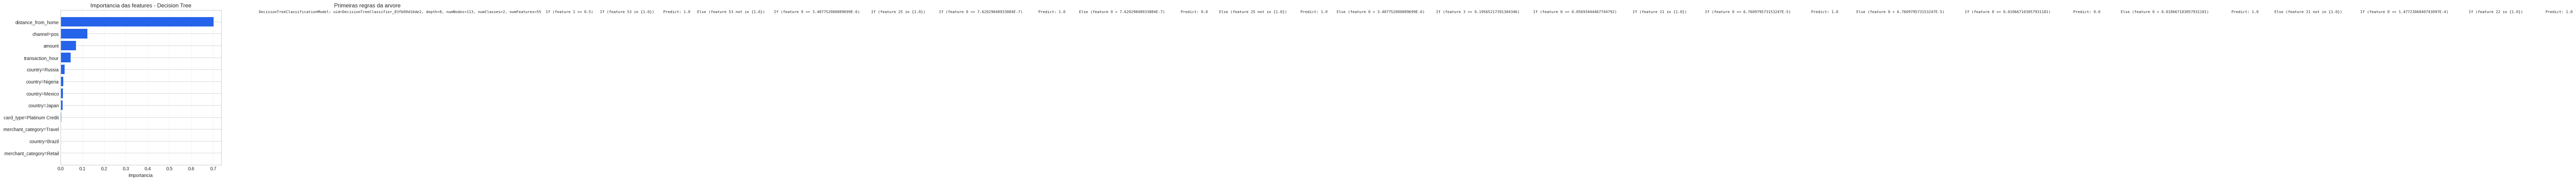

In [61]:
# Explicabilidade da arvore de decisao
# Grafico de importancia das features e recorte das primeiras regras.

feature_metadata = train_prepared_dataframe.schema["features"].metadata
feature_attributes = []

for attribute_group in feature_metadata.get("ml_attr", {}).get("attrs", {}).values():
    feature_attributes.extend(attribute_group)

feature_attributes = sorted(feature_attributes, key=lambda attribute: attribute["idx"])


def format_feature_name(raw_name):
    if raw_name.startswith("scaled_numeric_features_") or raw_name.startswith("numeric_features_"):
        feature_index = int(raw_name.rsplit("_", 1)[1])
        if feature_index < len(numeric_columns):
            return numeric_columns[feature_index]

    return (
        raw_name
        .replace("_ohe_", "=")
        .replace("_index", "")
        .replace("scaled_numeric_features", "numeric_features")
    )


feature_names = [
    format_feature_name(attribute.get("name", f"feature_{attribute['idx']}"))
    for attribute in feature_attributes
]

if len(feature_names) != feature_dimension:
    feature_names = [f"feature_{feature_index}" for feature_index in range(feature_dimension)]

feature_importance_values = decision_tree_model.featureImportances.toArray()
feature_importance_rows = [
    (feature_names[feature_index], float(importance_value))
    for feature_index, importance_value in enumerate(feature_importance_values)
    if importance_value > 0
]

feature_importance_rows = sorted(feature_importance_rows, key=lambda row: row[1], reverse=True)
top_feature_importance_rows = feature_importance_rows[:12]

decision_tree_debug_lines = decision_tree_model.toDebugString.splitlines()
decision_tree_rule_excerpt = "".join(decision_tree_debug_lines[:28])

print(f"Profundidade da arvore: {decision_tree_model.depth}")
print(f"Numero de nos: {decision_tree_model.numNodes}")
print(f"Features com importancia maior que zero: {len(feature_importance_rows)}")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6),
    gridspec_kw={"width_ratios": [1.0, 1.35]}
)

ax_importance, ax_rules = axes

if top_feature_importance_rows:
    feature_labels = [row[0] for row in reversed(top_feature_importance_rows)]
    feature_values = [row[1] for row in reversed(top_feature_importance_rows)]

    ax_importance.barh(feature_labels, feature_values, color=PLOT_COLORS["primary"])
    ax_importance.set_title("Importancia das features - Decision Tree")
    ax_importance.set_xlabel("Importancia")
    ax_importance.grid(axis="x", alpha=0.25)
else:
    ax_importance.text(0.5, 0.5, "Sem features com importancia > 0", ha="center", va="center")
    ax_importance.axis("off")

ax_rules.axis("off")
ax_rules.set_title("Primeiras regras da arvore")
ax_rules.text(
    0,
    1,
    decision_tree_rule_excerpt,
    va="top",
    ha="left",
    family="monospace",
    fontsize=8,
    transform=ax_rules.transAxes
)

plt.tight_layout()
plt.show()

## Logistic Regression

In [46]:
logistic_regression_classifier = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    maxIter=30,
    regParam=0.0,
    elasticNetParam=0.0
)

logistic_regression_model = logistic_regression_classifier.fit(train_prepared_dataframe)
logistic_regression_test_predictions = logistic_regression_model.transform(test_prepared_dataframe)

## Rede Neural

In [47]:
mlp_layers = [feature_dimension, 16, 8, 2]

multilayer_perceptron_classifier = MultilayerPerceptronClassifier(
    labelCol="label",
    featuresCol="features",
    layers=mlp_layers,
    maxIter=25,
    seed=42,
    blockSize=128
)

multilayer_perceptron_model = multilayer_perceptron_classifier.fit(train_prepared_dataframe)
multilayer_perceptron_test_predictions = multilayer_perceptron_model.transform(test_prepared_dataframe)

## Comparacao das metricas

In [48]:
evaluation_results = [
    evaluate_predictions(decision_tree_test_predictions, "Decision Tree", "test"),
    evaluate_predictions(logistic_regression_test_predictions, "Logistic Regression", "test"),
    evaluate_predictions(multilayer_perceptron_test_predictions, "Rede Neural", "test")
]

evaluation_dataframe = spark.createDataFrame(evaluation_results)
evaluation_dataframe.createOrReplaceTempView("model_evaluation_results")

In [49]:
spark.sql("""
    SELECT
        model,
        dataset,
        accuracy,
        f1,
        weighted_precision,
        weighted_recall,
        auc_roc
    FROM model_evaluation_results
    ORDER BY dataset, f1 DESC, auc_roc DESC
""").show(truncate=False)

+-------------------+-------+--------+------+------------------+---------------+-------+
|model              |dataset|accuracy|f1    |weighted_precision|weighted_recall|auc_roc|
+-------------------+-------+--------+------+------------------+---------------+-------+
|Decision Tree      |test   |0.9285  |0.9313|0.9395            |0.9285         |0.8896 |
|Logistic Regression|test   |0.908   |0.9121|0.9235            |0.908          |0.9682 |
|Rede Neural        |test   |0.9065  |0.9108|0.9225            |0.9065         |0.9673 |
+-------------------+-------+--------+------+------------------+---------------+-------+



### Grafico comparativo das metricas no teste

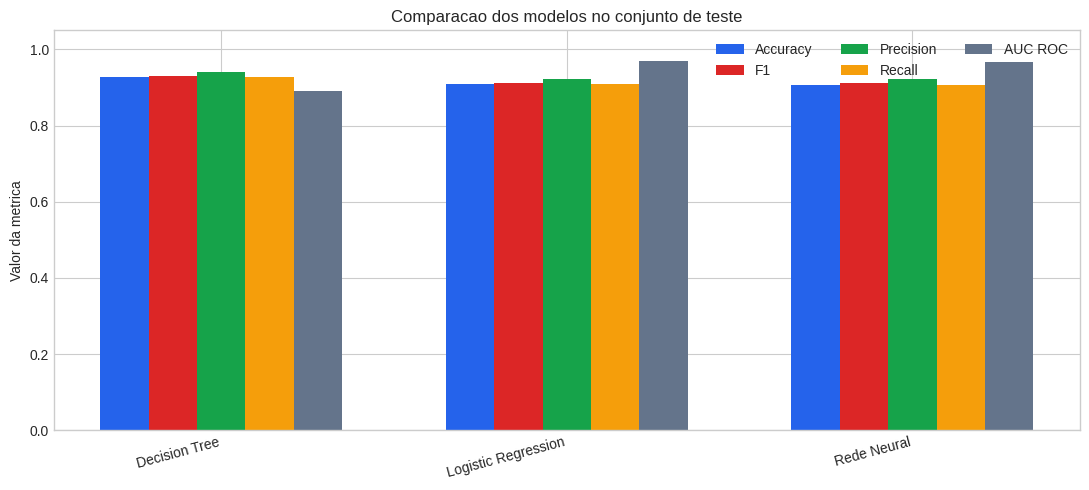

In [50]:
model_metric_rows = spark.sql("""
    SELECT
        model,
        accuracy,
        f1,
        weighted_precision,
        weighted_recall,
        auc_roc
    FROM model_evaluation_results
    WHERE dataset = 'test'
    ORDER BY f1 DESC, auc_roc DESC
""").collect()

metric_columns = ["accuracy", "f1", "weighted_precision", "weighted_recall", "auc_roc"]
metric_labels = ["Accuracy", "F1", "Precision", "Recall", "AUC ROC"]
metric_colors = [
    PLOT_COLORS["primary"],
    PLOT_COLORS["risk"],
    PLOT_COLORS["success"],
    PLOT_COLORS["warning"],
    PLOT_COLORS["muted"],
]

model_names = [row["model"] for row in model_metric_rows]
x_positions = list(range(len(model_names)))
bar_width = 0.14

fig, ax = plt.subplots(figsize=(11, 5))

for metric_index, (metric_column, metric_label, metric_color) in enumerate(zip(metric_columns, metric_labels, metric_colors)):
    offsets = [position + (metric_index - 2) * bar_width for position in x_positions]
    values = [float(row[metric_column]) for row in model_metric_rows]
    ax.bar(offsets, values, width=bar_width, label=metric_label, color=metric_color)

ax.set_title("Comparacao dos modelos no conjunto de teste")
ax.set_ylabel("Valor da metrica")
ax.set_xticks(x_positions)
ax.set_xticklabels(model_names, rotation=15, ha="right")
ax.set_ylim(0, 1.05)
ax.legend(ncol=3)
plt.tight_layout()
plt.show()

## Matrizes de confusao no conjunto de teste

In [51]:
decision_tree_test_predictions.selectExpr("CAST(label AS INT) AS label", "CAST(prediction AS INT) AS prediction").createOrReplaceTempView("decision_tree_test_predictions")
logistic_regression_test_predictions.selectExpr("CAST(label AS INT) AS label", "CAST(prediction AS INT) AS prediction").createOrReplaceTempView("logistic_regression_test_predictions")
multilayer_perceptron_test_predictions.selectExpr("CAST(label AS INT) AS label", "CAST(prediction AS INT) AS prediction").createOrReplaceTempView("multilayer_perceptron_test_predictions")

In [52]:
spark.sql("SELECT 'Decision Tree' AS model, label, prediction, COUNT(*) AS total FROM decision_tree_test_predictions GROUP BY label, prediction ORDER BY label, prediction").show(truncate=False)

spark.sql("SELECT 'Logistic Regression' AS model, label, prediction, COUNT(*) AS total FROM logistic_regression_test_predictions GROUP BY label, prediction ORDER BY label, prediction").show(truncate=False)

spark.sql("SELECT 'Rede Neural' AS model, label, prediction, COUNT(*) AS total FROM multilayer_perceptron_test_predictions GROUP BY label, prediction ORDER BY label, prediction").show(truncate=False)

+-------------+-----+----------+-------+
|model        |label|prediction|total  |
+-------------+-----+----------+-------+
|Decision Tree|0    |0         |1108729|
|Decision Tree|0    |1         |89706  |
|Decision Tree|1    |0         |17294  |
|Decision Tree|1    |1         |280662 |
+-------------+-----+----------+-------+

+-------------------+-----+----------+-------+
|model              |label|prediction|total  |
+-------------------+-----+----------+-------+
|Logistic Regression|0    |0         |1086330|
|Logistic Regression|0    |1         |112105 |
|Logistic Regression|1    |0         |25585  |
|Logistic Regression|1    |1         |272371 |
+-------------------+-----+----------+-------+

+-----------+-----+----------+-------+
|model      |label|prediction|total  |
+-----------+-----+----------+-------+
|Rede Neural|0    |0         |1084445|
|Rede Neural|0    |1         |113990 |
|Rede Neural|1    |0         |25880  |
|Rede Neural|1    |1         |272076 |
+-----------+-----+--

### Graficos das matrizes de confusao no teste

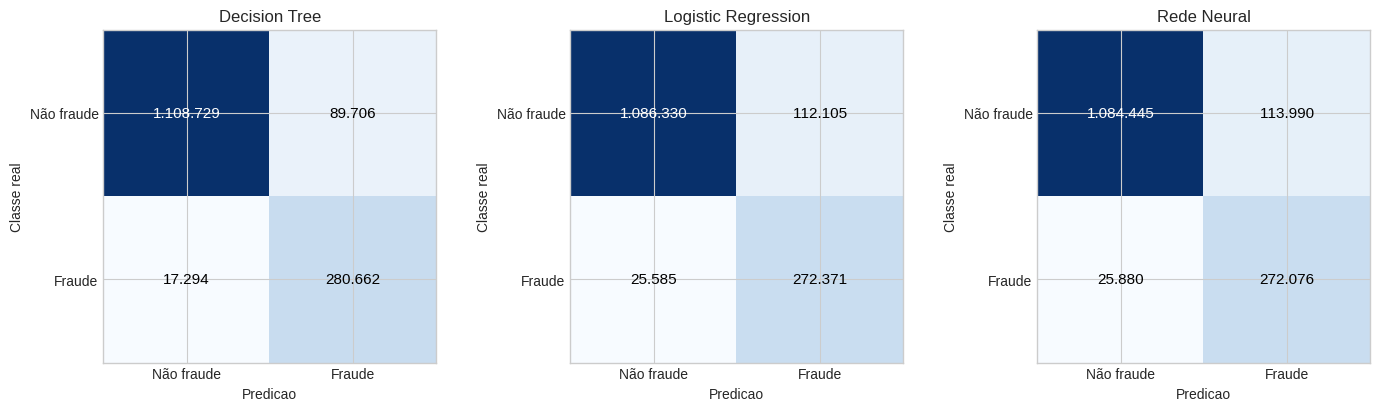

In [57]:
confusion_rows = spark.sql("""
    SELECT 'Decision Tree' AS model, label, prediction, COUNT(*) AS total
    FROM decision_tree_test_predictions
    GROUP BY label, prediction

    UNION ALL

    SELECT 'Logistic Regression' AS model, label, prediction, COUNT(*) AS total
    FROM logistic_regression_test_predictions
    GROUP BY label, prediction

    UNION ALL

    SELECT 'Rede Neural' AS model, label, prediction, COUNT(*) AS total
    FROM multilayer_perceptron_test_predictions
    GROUP BY label, prediction
""").collect()

model_names = ["Decision Tree", "Logistic Regression", "Rede Neural"]
confusion_matrices = {model_name: [[0, 0], [0, 0]] for model_name in model_names}

for row in confusion_rows:
    confusion_matrices[row["model"]][int(row["label"])][int(row["prediction"])] = int(row["total"])

fig, axes = plt.subplots(1, len(model_names), figsize=(14, 4), constrained_layout=True)

for ax, model_name in zip(axes, model_names):
    matrix = confusion_matrices[model_name]
    ax.imshow(matrix, cmap="Blues")
    threshold = max(max(row_values) for row_values in matrix) / 2

    for real_class in range(2):
        for predicted_class in range(2):
            value = matrix[real_class][predicted_class]
            text_color = "white" if value > threshold else "black"
            ax.text(
                predicted_class,
                real_class,
                format_integer(value),
                ha="center",
                va="center",
                color=text_color,
                fontsize=11,
            )

    ax.set_title(model_name)
    ax.set_xlabel("Predicao")
    ax.set_ylabel("Classe real")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Não fraude", "Fraude"])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Não fraude", "Fraude"])

plt.show()

## Comparacao final dos modelos no conjunto de teste


In [54]:
spark.sql("""
    SELECT
        model,
        accuracy,
        f1,
        weighted_precision,
        weighted_recall,
        auc_roc
    FROM model_evaluation_results
    WHERE dataset = 'test'
    ORDER BY f1 DESC, auc_roc DESC
""").show(truncate=False)

+-------------------+--------+------+------------------+---------------+-------+
|model              |accuracy|f1    |weighted_precision|weighted_recall|auc_roc|
+-------------------+--------+------+------------------+---------------+-------+
|Decision Tree      |0.9285  |0.9313|0.9395            |0.9285         |0.8896 |
|Logistic Regression|0.908   |0.9121|0.9235            |0.908          |0.9682 |
|Rede Neural        |0.9065  |0.9108|0.9225            |0.9065         |0.9673 |
+-------------------+--------+------+------------------+---------------+-------+

